In [2]:
from craftax.craftax_classic.train.metacontroller_jax import ClassicMetaController
from craftax.craftax_classic.envs.craftax_state import StaticEnvParams
from craftax.craftax_classic.constants import Action
from craftax.craftax_classic.train.visualize import replay_episode

import jax

In [3]:
metacontroller = ClassicMetaController(static_parameters=StaticEnvParams(num_players=4))

In [4]:
import pickle
with open("params_lstm_newwesst.p", "rb") as f:
    params = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'params_lstm_newwesst.p'

In [4]:
metacontroller.rng = jax.random.PRNGKey(4253)
states, actions, logits, rewards = metacontroller.run_one_episode(params)

IntSlider(value=0, description='env_step', max=514)

Dropdown(description='Player:', options=('Agent 0', 'Agent 1', 'Agent 2', 'Agent 3'), value='Agent 0')

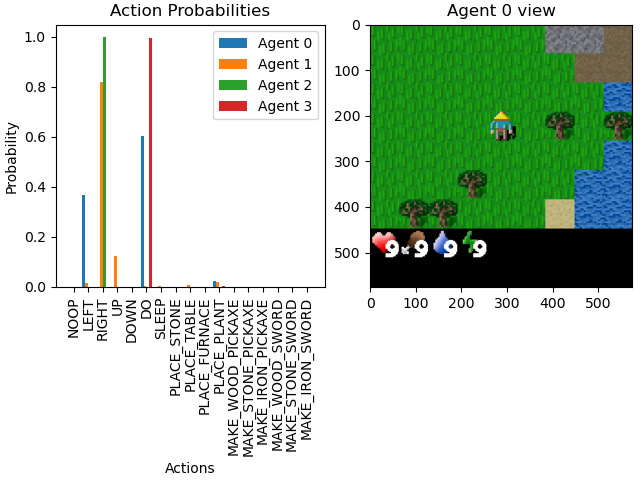

In [5]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
from craftax.craftax_classic.renderer import render_craftax_pixels
%matplotlib widget

# Assuming `states` and `logits` are defined elsewhere in your notebook
env_step = 0
selected_agent = 0

# Define the slider
slider = widgets.IntSlider(min=0, max=len(actions)-1, value=env_step, description='env_step')
player_selector = widgets.Dropdown(
    options=[f'Agent {i}' for i in range(metacontroller.static_params.num_players)],
    value='Agent 0',
    description='Player:',
)

# Define the slider callback function
def update_env_step(change):
    global env_step
    env_step = change.new
    update_plot()

def update_agent(change):
    global selected_agent
    selected_agent = int(change.new.split(" ")[1])
    update_plot()

# Register the slider callback function
slider.observe(update_env_step, 'value')
player_selector.observe(update_agent, 'value')

# Display the slider
display(slider)
display(player_selector)

# Initial plot setup
fig, axs = plt.subplots(1, 2, layout="constrained")
probs = jax.nn.softmax(logits[env_step], axis=-1)

# Define the x-axis labels
x_labels = [Action(a).name for a in Action]

bar_width = 1 / (metacontroller.static_params.num_players + 1)

# Plot the grouped bar chart
bars = []
for i, agent_probs in enumerate(probs):
    bar = axs[0].bar([x + bar_width*i for x in range(len(x_labels))], agent_probs.flatten(), width=bar_width, label=f'Agent {i}')
    bars.append(bar)


axs[0].set_xticks(np.arange(len(x_labels)) + 1.5 * bar_width, x_labels, rotation="vertical")

# Set the labels and title
axs[0].set_xlabel('Actions')
axs[0].set_ylabel('Probability')
axs[0].set_title('Action Probabilities')

# Add a legend
axs[0].legend()

# render frame
im = axs[1].imshow(np.asarray(render_craftax_pixels(states[env_step], 64, metacontroller.static_params.num_players, 0), dtype=np.uint8))
axs[1].title.set_text(f"{player_selector.value} view")

# Update plot function
def update_plot():
    global env_step
    probs = jax.nn.softmax(logits[env_step], axis=-1)
    for i, bar in enumerate(bars):
        for rect, h in zip(bar, probs[i].flatten()):
            rect.set_height(h)
    # rescale y-axis
    axs[0].set_ylim(0, 1.1 * np.max(probs))
    # update frame
    # axs[1].cla()
    # axs[1].imshow(np.asarray(render_craftax_pixels(states[env_step], 64, 4, player=selected_agent), dtype=np.uint8))
    im.set_data(np.asarray(render_craftax_pixels(states[env_step], 64, metacontroller.static_params.num_players, player=selected_agent), dtype=np.uint8))
    axs[1].title.set_text(f"{player_selector.value} view")
    fig.canvas.draw_idle()

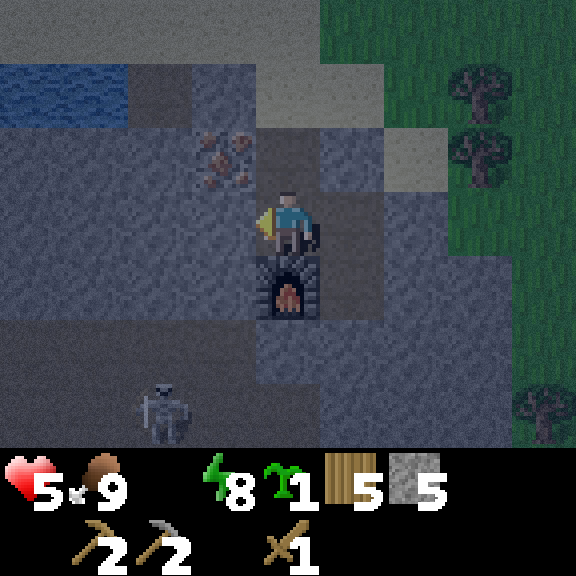

In [8]:
from PIL import Image
import io
import IPython.display as display

Image.fromarray(np.asarray(render_craftax_pixels(states[244], 64, metacontroller.static_params.num_players, player=0), dtype=np.uint8))

In [6]:
import cv2
import numpy as np
from craftax.craftax_classic.renderer import render_craftax_pixels

player_to_render = 2

# Example render function
def render(frame_number):
    data = render_craftax_pixels(states[frame_number], 64, 4, player_to_render)
    return np.asarray(data, dtype=np.uint8)[..., ::-1]

# Video writer setup
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('output_new.mp4', fourcc, 15.0, (576, 576))

# Generate and write frames
for frame_number in range(len(states)):
    frame = render(frame_number)
    out.write(frame)
# Release the video writer
out.release()

Compute average achievements

In [5]:
import jax
import jax.numpy as jnp
from craftax.craftax_classic.envs.craftax_symbolic_env import (
    CraftaxClassicSymbolicEnvNoAutoReset,
)
from functools import partial

no_reset_env = CraftaxClassicSymbolicEnvNoAutoReset(metacontroller.static_params)


@jax.vmap
def eval_agent(model_param, next_obs, lstm_state, done, rng):
    logits, value, lstm_state = metacontroller.agent.apply(model_param, next_obs, lstm_state, done)  # pyright: ignore
    action = jax.random.categorical(rng, logits).squeeze()
    return action, logits, lstm_state


step_fn = jax.vmap(no_reset_env.step, in_axes=(0, 0, 1, None), out_axes=(1, 0, 1, 1, 0))
reset_fn = jax.vmap(no_reset_env.reset, in_axes=(0, None), out_axes=(1, 0))


@partial(jax.jit, static_argnums=(1, 2))
def compute_achievement_performance(params, num_parallel=50, max_timesteps=1000):
    rng, _rng = jax.random.split(metacontroller.rng)
    next_obs, env_state = reset_fn(
        jax.random.split(_rng, num_parallel), metacontroller.env_params
    )
    next_done = jnp.zeros(
        (metacontroller.static_params.num_players, num_parallel), dtype=int
    )
    next_lstm_states = (
        jnp.zeros((metacontroller.static_params.num_players, num_parallel, 32)),
        jnp.zeros((metacontroller.static_params.num_players, num_parallel, 32)),
    )

    def do_step(carry, _):
        next_obs, env_state, next_lstm_states, next_done, rng = carry
        print(next_obs.shape)
        rng, _rng = jax.random.split(rng)
        agent_actions, agent_logits, next_lstm_states = eval_agent(
            params,
            next_obs,
            next_lstm_states,
            next_done,
            jax.random.split(_rng, metacontroller.static_params.num_players),
        )
        next_obs, env_state, reward, next_done, _info = step_fn(
            jax.random.split(_rng, num_parallel),
            env_state,
            agent_actions,
            metacontroller.env_params,
        )
        return (next_obs, env_state, next_lstm_states, next_done, rng), None

    (_, env_state, _, _, _), _ = jax.lax.scan(
        do_step,
        (next_obs, env_state, next_lstm_states, next_done, _rng),
        jnp.arange(max_timesteps),
    )
    return env_state.achievements.mean(axis=0)

NameError: name 'np' is not defined

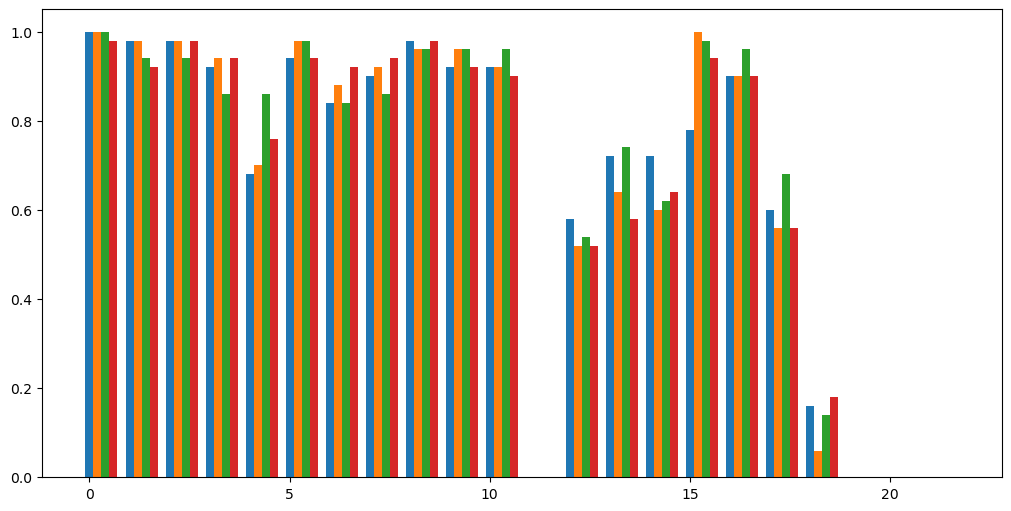

In [7]:
from craftax.craftax_classic.constants import Achievement
from matplotlib import pyplot as plt

results = compute_achievement_performance(params, num_parallel=50, max_timesteps=1000)
fig, ax = plt.subplots(layout="constrained", figsize=(10, 5))
x_labels = [Achievement(a).name for a in Achievement]
bar_width = 1 / (metacontroller.static_params.num_players + 1)
for i, result in enumerate(results):
    ax.bar([x + bar_width*i for x in range(len(x_labels))], result, width=bar_width, label=f'Agent {i}')

ax.set_xticks(np.arange(len(x_labels)) + 1.5 * bar_width, x_labels, rotation="vertical")
ax.set_xlabel('Achievements')
ax.set_ylabel('Probability')
ax.set_title('Achievement Probabilities')
ax.legend()

In [8]:
# save results.mean(axis=0) to csv file
import pandas as pd
df = pd.DataFrame(results.mean(axis=0), columns=["Probability"])
df.index = [Achievement(a).name for a in Achievement]
df.to_csv("achievement_probabilities_v3.csv")

In [70]:
fig.savefig("lstm_achievement_mean.pdf")

In [4]:
import pickle
with open("log_lstm_newest.p", "rb") as f:
    log = pickle.load(f)

log

Train Log with 25 snapshots and 500 items of 3 different statistics

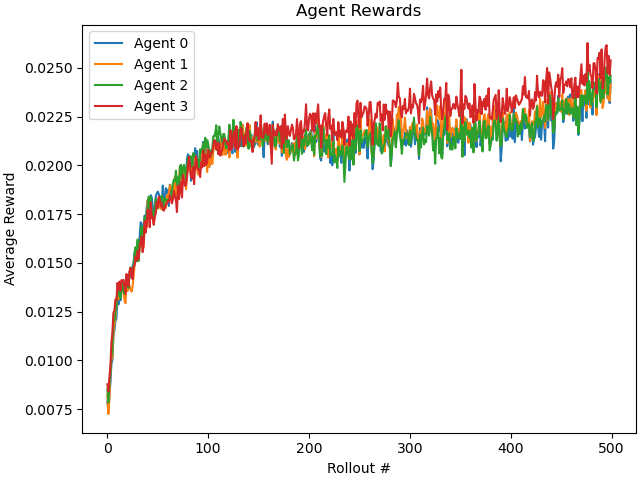

In [5]:
import matplotlib.pyplot as plt
%matplotlib widget

fig, ax = plt.subplots(layout="constrained")
for agent in range(log.static_env_params.num_players):
    ax.plot([x[1][agent] for x in log.stats["reward"]], label=f"Agent {agent}")

ax.set_xlabel("Rollout #")
ax.set_ylabel("Average Reward")
ax.set_title("Agent Rewards")
ax.legend()

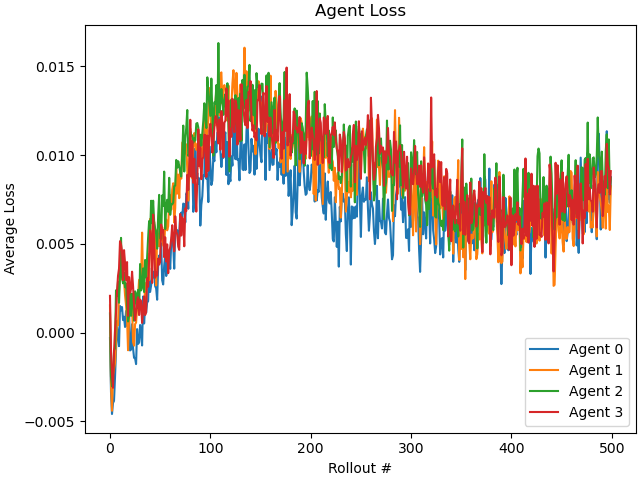

In [9]:
import matplotlib.pyplot as plt
%matplotlib widget

fig, ax = plt.subplots(layout="constrained")
for agent in range(log.static_env_params.num_players):
    ax.plot([x[1][agent] for x in log.stats["loss"]], label=f"Agent {agent}")

ax.set_xlabel("Rollout #")
ax.set_ylabel("Average Loss")
ax.set_title("Agent Loss")
ax.legend()

In [5]:
import jax
import jax.numpy as jnp
from craftax.craftax_classic.envs.craftax_symbolic_env import (
    CraftaxClassicSymbolicEnvNoAutoReset,
)
from functools import partial

no_reset_env = CraftaxClassicSymbolicEnvNoAutoReset(metacontroller.static_params)


@jax.vmap
def eval_agent(model_param, next_obs, lstm_state, done, rng):
    logits, value, lstm_state = metacontroller.agent.apply(model_param, next_obs, lstm_state, done)  # pyright: ignore
    action = jax.random.categorical(rng, logits).squeeze()
    return action, logits, lstm_state


step_fn = jax.vmap(no_reset_env.step, in_axes=(0, 0, 1, None), out_axes=(1, 0, 1, 1, 0))
reset_fn = jax.vmap(no_reset_env.reset, in_axes=(0, None), out_axes=(1, 0))


@partial(jax.vmap, in_axes=(0, None, None), out_axes=1)
def eval_params(params, num_parallel, max_timesteps):
    rng, _rng = jax.random.split(metacontroller.rng)
    next_obs, env_state = reset_fn(
        jax.random.split(_rng, num_parallel), metacontroller.env_params
    )
    next_done = jnp.zeros(
        (metacontroller.static_params.num_players, num_parallel), dtype=int
    )
    next_lstm_states = (
        jnp.zeros((metacontroller.static_params.num_players, num_parallel, 32)),
        jnp.zeros((metacontroller.static_params.num_players, num_parallel, 32)),
    )

    def do_step(carry, _):
        next_obs, env_state, next_lstm_states, next_done, rng = carry
        rng, _rng = jax.random.split(rng)
        agent_actions, agent_logits, next_lstm_states = eval_agent(
            params,
            next_obs,
            next_lstm_states,
            next_done,
            jax.random.split(_rng, metacontroller.static_params.num_players),
        )
        next_obs, env_state, reward, next_done, _info = step_fn(
            jax.random.split(_rng, num_parallel),
            env_state,
            agent_actions,
            metacontroller.env_params,
        )
        return (next_obs, env_state, next_lstm_states, next_done, rng), None

    (_, env_state, _, _, _), _ = jax.lax.scan(
        do_step,
        (next_obs, env_state, next_lstm_states, next_done, _rng),
        jnp.arange(max_timesteps),
    )
    achievements = env_state.achievements.sum(axis=-1)
    return achievements.mean(axis=0), achievements.std(axis=0, ddof=1)


@partial(jax.jit, static_argnums=(1, 2))
def average_achievements_ppo(model_params, num_parallel=10, max_timesteps=1000):
    params_tree = jax.tree_util.tree_map(lambda *x: jnp.stack(x, axis=0), *model_params)
    return eval_params(params_tree, num_parallel, max_timesteps)

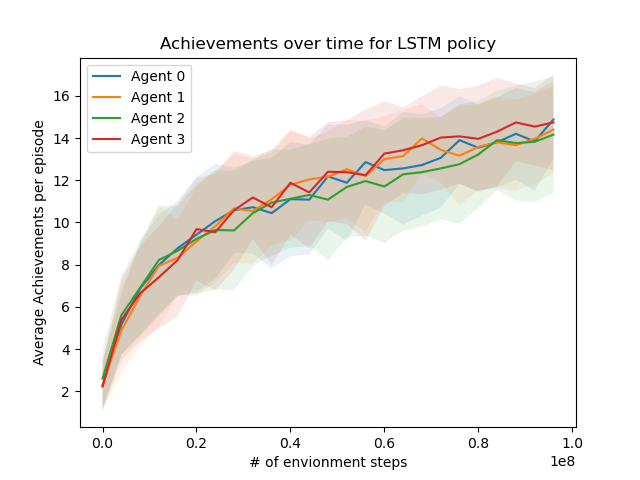

In [6]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget

x, unzipped_params = zip(*log.model_snapshots)
x = np.array(x) * 200000
y, y_std = average_achievements_ppo(unzipped_params, num_parallel=50)

fig, ax = plt.subplots()
for agent in range(len(y)):
    ax.plot(x, y[agent], label=f"Agent {agent}")
    ax.fill_between(x, y[agent] - y_std[agent], y[agent] + y_std[agent], alpha=0.1)

ax.set_xlabel("# of envionment steps")
ax.set_ylabel("Average Achievements per episode")
ax.set_title("Achievements over time for LSTM policy")
ax.legend()

In [12]:
# save average achievement as csv
import csv

average_achievements_all = jnp.mean(y, axis=0)

with open("lstm_achievements.csv", "w") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "achievement"])
    for i, step in enumerate(x):
        writer.writerow([step, average_achievements_all[i]])

In [9]:
average_achievements_all

Array([ 2.345    ,  5.255    ,  6.7299995,  7.8849998,  8.495    ,
        9.3550005,  9.764999 , 10.360001 , 10.719999 , 10.799999 ,
       11.47     , 11.459999 , 11.955    , 12.115    , 12.315001 ,
       12.61     , 12.85     , 13.184999 , 13.2699995, 13.475    ,
       13.574999 , 13.95     , 14.09     , 14.04     , 14.545    ],      dtype=float32)

In [27]:
fig.savefig("lstm_achievements.pdf")

Ignore